<a href="https://colab.research.google.com/github/NazHub1993/LinearRegression_VS_SVR/blob/main/LR_vs_SVR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🏗️** Predicting Concrete Compressive Strength
## A Comparative Study of Linear Regression vs SVR  
### with PCA Dimensionality Reduction & GridSearchCV Hyperparameter Tuning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV , cross_val_score
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
df = pd.read_excel(url)

# Rename columns for readability
df.columns = [
    "Cement", "BlastFurnaceSlag", "FlyAsh", "Water",
    "Superplasticizer", "CoarseAggregate", "FineAggregate",
    "Age", "CompressiveStrength"
]


In [3]:
df.head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [4]:
df.describe()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [5]:
df.dtypes

,0
Cement,float64
BlastFurnaceSlag,float64
FlyAsh,float64
Water,float64
Superplasticizer,float64
CoarseAggregate,float64
FineAggregate,float64
Age,int64
CompressiveStrength,float64


In [6]:
df.isnull().sum()

,0
Cement,0
BlastFurnaceSlag,0
FlyAsh,0
Water,0
Superplasticizer,0
CoarseAggregate,0
FineAggregate,0
Age,0
CompressiveStrength,0


#So no missing values

#Let's do exploratory data analysis

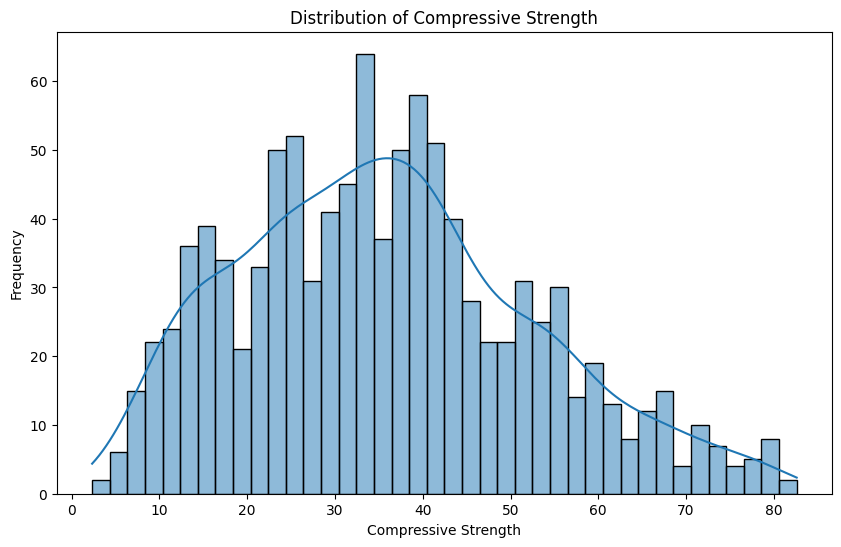

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(df['CompressiveStrength'],bins=40,kde=True)
plt.title('Distribution of Compressive Strength')
plt.xlabel('Compressive Strength')
plt.ylabel('Frequency')
plt.show()

#Now showing the correlation between variables

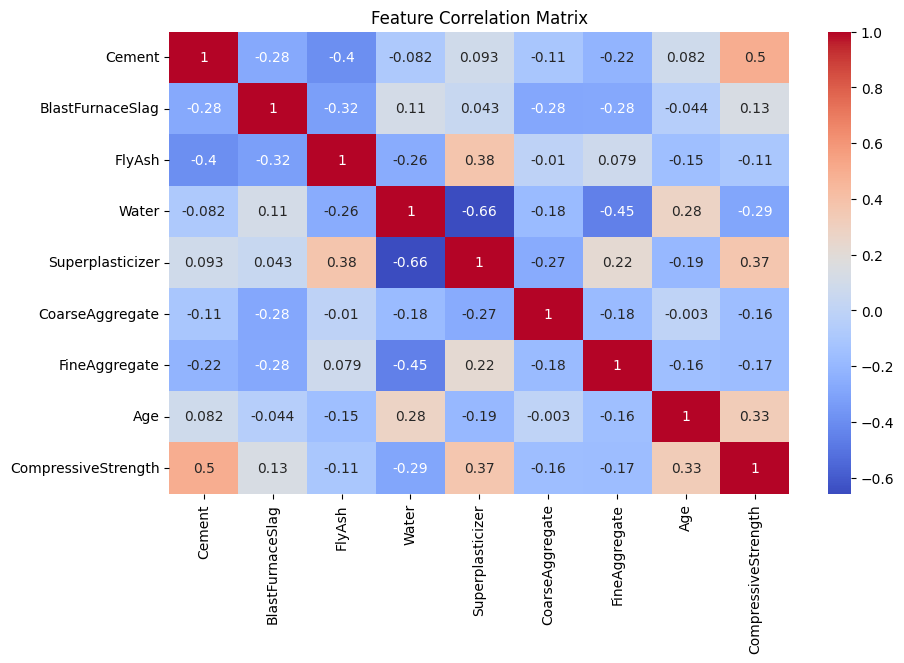

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

#Here we can see Cement , Superplasticizer and Age are strongly correlated

#Train_Test_Split

In [12]:
X=df.drop("CompressiveStrength",axis=1)
Y=df['CompressiveStrength']

x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

#StandardScaling the data

In [14]:
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

#Applying the PCA to reduce dimensions

In [15]:
pca_full=PCA()
x_train_pca=pca_full.fit_transform(x_train_scaled)

pca_full.explained_variance_ratio_


array([0.2801617 , 0.17910071, 0.16830488, 0.12802833, 0.11812444,
       0.099379  , 0.02301989, 0.00388105])

In [16]:
cumsum_explained_variance=np.cumsum(pca_full.explained_variance_ratio_)


Text(0.5, 1.0, 'Cumulative Explained Variance vs Number of Components')

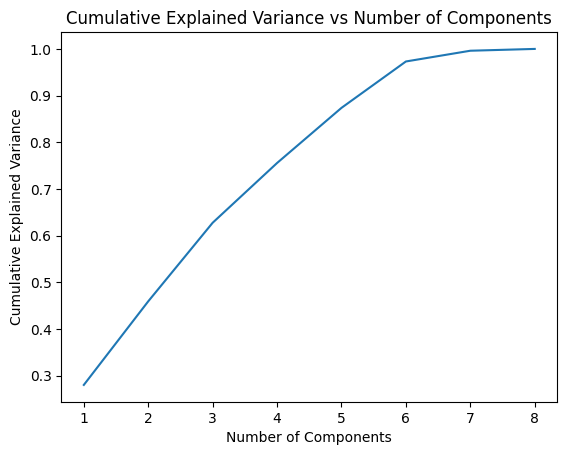

In [18]:
plt.plot(range(1,len(pca_full.explained_variance_ratio_)+1),cumsum_explained_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs Number of Components")

So 6 is the number of components where the graph gets steep.

In [19]:
pca=PCA(n_components=6)
x_train_pca=pca.fit_transform(x_train_scaled)
x_test_pca=pca.transform(x_test_scaled)

#Using Linear Regression

In [20]:
lr=LinearRegression()
lr.fit(x_train_pca,y_train)
y_pred=lr.predict(x_test_pca)



In [23]:
from sklearn.metrics import accuracy_score

In [26]:
print("Mean Squared Error: ",mean_squared_error(y_test,y_pred))
print("R2 Score: ",r2_score(y_test,y_pred))
print("Mean Absolute Error: ",mean_absolute_error(y_test,y_pred))


Mean Squared Error:  111.33431082145735
R2 Score:  0.5679375943145379
Mean Absolute Error:  8.48761321861497


#We can see the Mean Squared Score is very large here!!!

#Using SupportVectorRegressor

In [27]:
from sklearn.model_selection import RandomizedSearchCV

In [31]:
param_grid = {
    "C"      : [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5, 1.0],
    "kernel" : ["linear", "rbf", "poly"],
    "gamma"  : ["scale", "auto"]   # ignored by linear kernel
}

grid=RandomizedSearchCV(
    estimator=SVR(),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(x_train_pca,y_train)
print("Best Parameters:\n")
print(grid.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:

{'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.5, 'C': 10}


In [35]:
svr_model=grid.best_estimator_
svr_model.fit(x_train_pca,y_train)
y_pred=svr_model.predict(x_test_pca)

score=cross_val_score(svr_model,x_train_pca,y_train,cv=5,scoring='r2')
print("Cross-validation R2 Score:", score.mean())

Cross-validation R2 Score: 0.7804571552912645


In [36]:
r2_score(y_test,y_pred)

0.761438180361966

In [37]:
mean_squared_error(y_test,y_pred)

61.47286926196694

#So we can see that SVR performed well on this dataset because it contained non-linear data.